# 📐 Cálculo Diferencial e Integral I

`Matemática/Ciências` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Limites, derivadas, aplicações e integrais — o núcleo do Cálculo.**

Fundamento para todas as disciplinas de engenharia. O notebook resolve limites, deriva funções, traça retas tangentes e calcula integrais com o SymPy, além de gerar o cheat sheet.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


PDF gerado em Calculo_Diferencial_Integral_I.pdf
Páginas: 1


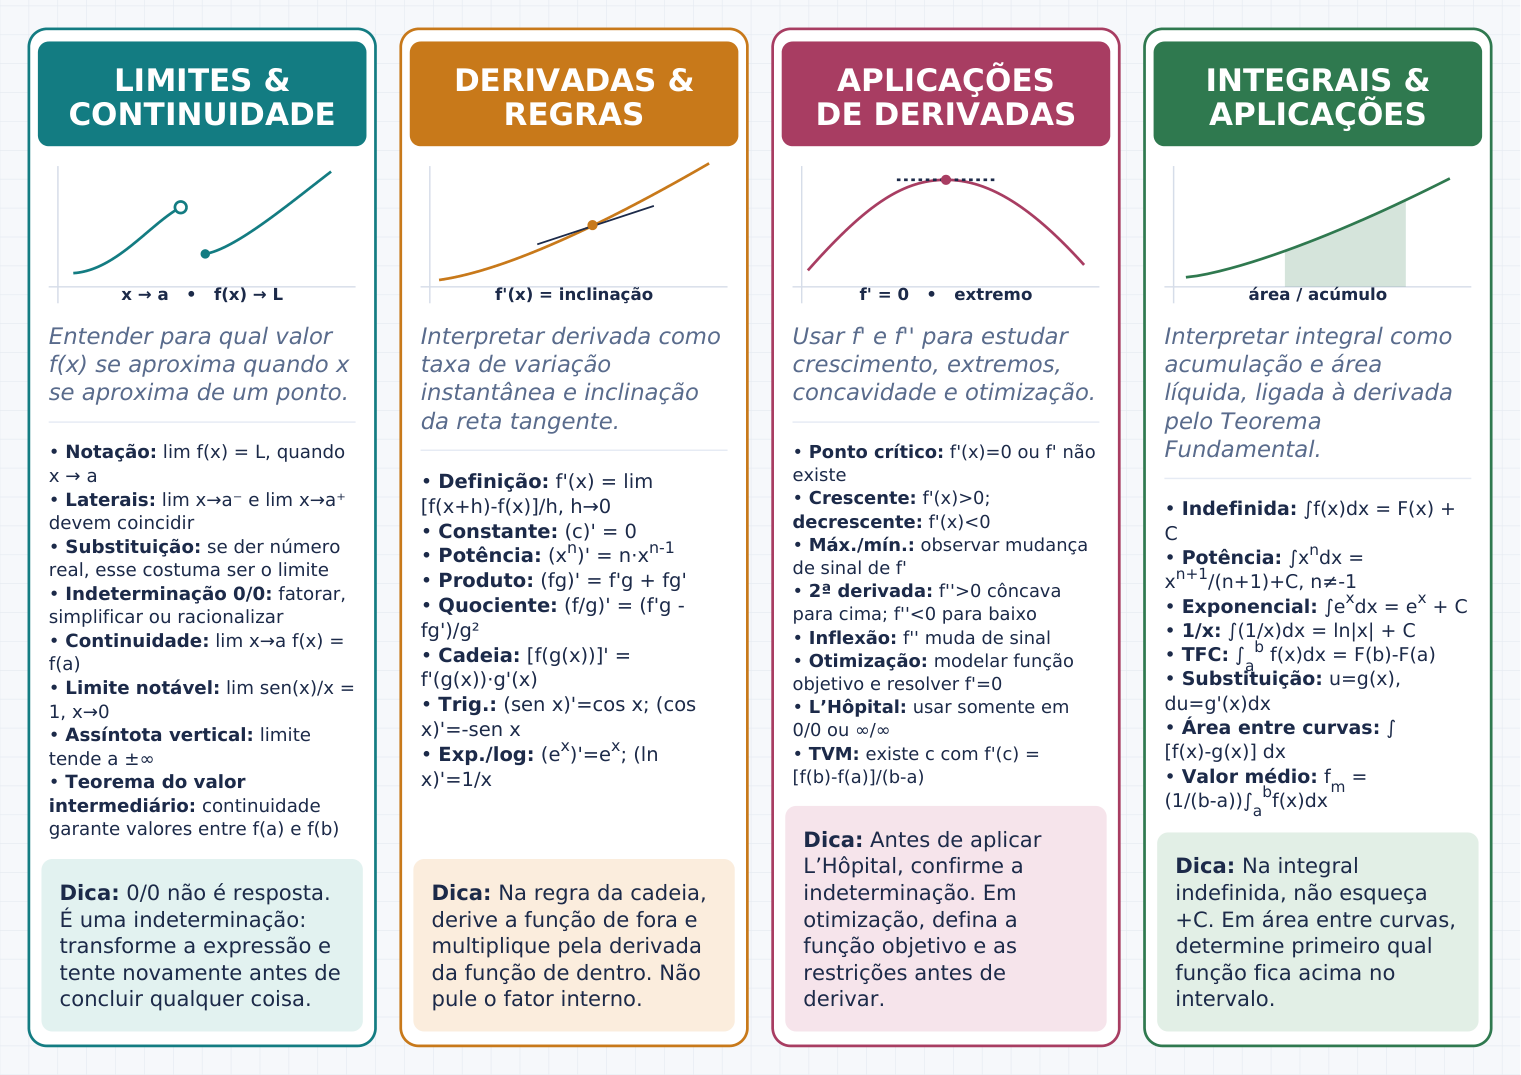

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Calculo_Diferencial_Integral_I.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond', normal='DVCond', bold='DVCond-Bold', italic='DVCond-Oblique', boldItalic='DVCond-Bold')

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'LIMITES &amp;<br/>CONTINUIDADE',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'limites',
        'idea': 'Entender para qual valor f(x) se aproxima quando x se aproxima de um ponto.',
        'formulas': [
            '<b>Notação:</b> lim f(x) = L, quando x → a',
            '<b>Laterais:</b> lim x→a⁻ e lim x→a⁺ devem coincidir',
            '<b>Substituição:</b> se der número real, esse costuma ser o limite',
            '<b>Indeterminação 0/0:</b> fatorar, simplificar ou racionalizar',
            '<b>Continuidade:</b> lim x→a f(x) = f(a)',
            '<b>Limite notável:</b> lim sen(x)/x = 1, x→0',
            '<b>Assíntota vertical:</b> limite tende a ±∞',
            '<b>Teorema do valor intermediário:</b> continuidade garante valores entre f(a) e f(b)',
        ],
        'tip': '0/0 não é resposta. É uma indeterminação: transforme a expressão e tente novamente antes de concluir qualquer coisa.',
    },
    {
        'title': 'DERIVADAS &amp;<br/>REGRAS',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'derivadas',
        'idea': 'Interpretar derivada como taxa de variação instantânea e inclinação da reta tangente.',
        'formulas': [
            '<b>Definição:</b> f\'(x) = lim [f(x+h)-f(x)]/h, h→0',
            '<b>Constante:</b> (c)\' = 0',
            '<b>Potência:</b> (x<super>n</super>)\' = n·x<super>n-1</super>',
            '<b>Produto:</b> (fg)\' = f\'g + fg\'',
            '<b>Quociente:</b> (f/g)\' = (f\'g - fg\')/g²',
            '<b>Cadeia:</b> [f(g(x))]\' = f\'(g(x))·g\'(x)',
            '<b>Trig.:</b> (sen x)\'=cos x; (cos x)\'=-sen x',
            '<b>Exp./log:</b> (e<super>x</super>)\'=e<super>x</super>; (ln x)\'=1/x',
        ],
        'tip': 'Na regra da cadeia, derive a função de fora e multiplique pela derivada da função de dentro. Não pule o fator interno.',
    },
    {
        'title': 'APLICAÇÕES<br/>DE DERIVADAS',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'aplicacoes',
        'idea': 'Usar f\' e f\'\' para estudar crescimento, extremos, concavidade e otimização.',
        'formulas': [
            '<b>Ponto crítico:</b> f\'(x)=0 ou f\' não existe',
            '<b>Crescente:</b> f\'(x)&gt;0; <b>decrescente:</b> f\'(x)&lt;0',
            '<b>Máx./mín.:</b> observar mudança de sinal de f\'',
            '<b>2ª derivada:</b> f\'\'&gt;0 côncava para cima; f\'\'&lt;0 para baixo',
            '<b>Inflexão:</b> f\'\' muda de sinal',
            '<b>Otimização:</b> modelar função objetivo e resolver f\'=0',
            '<b>L’Hôpital:</b> usar somente em 0/0 ou ∞/∞',
            '<b>TVM:</b> existe c com f\'(c) = [f(b)-f(a)]/(b-a)',
        ],
        'tip': 'Antes de aplicar L’Hôpital, confirme a indeterminação. Em otimização, defina a função objetivo e as restrições antes de derivar.',
    },
    {
        'title': 'INTEGRAIS &amp;<br/>APLICAÇÕES',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'integrais',
        'idea': 'Interpretar integral como acumulação e área líquida, ligada à derivada pelo Teorema Fundamental.',
        'formulas': [
            '<b>Indefinida:</b> ∫f(x)dx = F(x) + C',
            '<b>Potência:</b> ∫x<super>n</super>dx = x<super>n+1</super>/(n+1)+C, n≠-1',
            '<b>Exponencial:</b> ∫e<super>x</super>dx = e<super>x</super> + C',
            '<b>1/x:</b> ∫(1/x)dx = ln|x| + C',
            '<b>TFC:</b> ∫<sub>a</sub><super>b</super> f(x)dx = F(b)-F(a)',
            '<b>Substituição:</b> u=g(x), du=g\'(x)dx',
            '<b>Área entre curvas:</b> ∫ [f(x)-g(x)] dx',
            '<b>Valor médio:</b> f<sub>m</sub> = (1/(b-a))∫<sub>a</sub><super>b</super>f(x)dx',
        ],
        'tip': 'Na integral indefinida, não esqueça +C. Em área entre curvas, determine primeiro qual função fica acima no intervalo.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle('card_title', fontName='DVCond-Bold', fontSize=17.2, leading=18.6, textColor=WHITE, alignment=1)
STYLE_IDEA = ParagraphStyle('idea', fontName='DVCond-Oblique', fontSize=12.6, leading=15.6, textColor=MUTED)
STYLE_TIP = ParagraphStyle('tip', fontName='DVCond', fontSize=11.7, leading=14.7, textColor=INK)


def axis(c, ox, oy, dw, dh):
    ax_y = oy + dh * 0.12
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(ox, ax_y, ox + dw, ax_y)
    c.line(ox + dw * 0.03, oy, ox + dw * 0.03, oy + dh)
    return ax_y


def arrow(c, x1, y1, x2, y2, color, width=1.1, head=4):
    c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2)
    ang = math.atan2(y2-y1, x2-x1)
    for d in (2.55,-2.55):
        c.line(x2,y2,x2+head*math.cos(ang+d),y2+head*math.sin(ang+d))


def diagram_limites(c, ox, oy, dw, dh, color):
    ay = axis(c, ox, oy, dw, dh)
    x1 = ox + dw*0.43
    y1 = ay + dh*0.58
    p = c.beginPath(); p.moveTo(ox+dw*0.08, ay+dh*0.10)
    p.curveTo(ox+dw*0.22, ay+dh*0.12, x1-dw*0.10, y1-dh*0.12, x1, y1)
    c.setStrokeColor(color); c.setLineWidth(1.5); c.drawPath(p, stroke=1, fill=0)
    p2 = c.beginPath(); p2.moveTo(x1+dw*0.08, ay+dh*0.24)
    p2.curveTo(x1+dw*0.18, ay+dh*0.28, ox+dw*0.78, ay+dh*0.60, ox+dw*0.92, ay+dh*0.84)
    c.drawPath(p2, stroke=1, fill=0)
    c.setFillColor(WHITE); c.setStrokeColor(color); c.circle(x1,y1,3.2,stroke=1,fill=1)
    c.setFillColor(color); c.circle(x1+dw*0.08, ay+dh*0.24, 2.6, stroke=0, fill=1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.2); c.drawCentredString(ox+dw*0.50,oy+2,'x → a   •   f(x) → L')


def diagram_derivadas(c, ox, oy, dw, dh, color):
    ay = axis(c, ox, oy, dw, dh)
    p = c.beginPath(); p.moveTo(ox+dw*0.06, ay+dh*0.05)
    p.curveTo(ox+dw*0.28, ay+dh*0.12, ox+dw*0.60, ay+dh*0.46, ox+dw*0.94, ay+dh*0.90)
    c.setStrokeColor(color); c.setLineWidth(1.5); c.drawPath(p,stroke=1,fill=0)
    xm,ym=ox+dw*0.56, ay+dh*0.45
    c.setStrokeColor(INK); c.setLineWidth(1.0); c.line(xm-dw*0.18,ym-dh*0.14,xm+dw*0.20,ym+dh*0.14)
    c.setFillColor(color); c.circle(xm,ym,2.8,stroke=0,fill=1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.2); c.drawCentredString(ox+dw*0.50,oy+2,"f'(x) = inclinação")


def diagram_aplicacoes(c, ox, oy, dw, dh, color):
    ay = axis(c, ox, oy, dw, dh)
    xpk, ypk = ox+dw*0.50, ay+dh*0.78
    p = c.beginPath(); p.moveTo(ox+dw*0.05, ay+dh*0.12)
    p.curveTo(ox+dw*0.24, ay+dh*0.60, xpk-dw*0.14, ypk, xpk,ypk)
    p.curveTo(xpk+dw*0.14,ypk,ox+dw*0.78,ay+dh*0.58,ox+dw*0.95,ay+dh*0.16)
    c.setStrokeColor(color); c.setLineWidth(1.5); c.drawPath(p,stroke=1,fill=0)
    c.setStrokeColor(INK); c.setDash([2,2]); c.line(xpk-dw*0.16,ypk,xpk+dw*0.16,ypk); c.setDash([])
    c.setFillColor(color); c.circle(xpk,ypk,2.8,stroke=0,fill=1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.2); c.drawCentredString(ox+dw*0.50,oy+2,'f\' = 0   •   extremo')


def diagram_integrais(c, ox, oy, dw, dh, color):
    ay = axis(c, ox, oy, dw, dh)
    pts=[]
    for i in range(25):
        t=i/24
        x=ox+dw*(0.07+0.86*t)
        y=ay+dh*(0.07+0.72*(t**1.35))
        pts.append((x,y))
    p=c.beginPath(); p.moveTo(*pts[0])
    for pt in pts[1:]: p.lineTo(*pt)
    c.setStrokeColor(color); c.setLineWidth(1.5); c.drawPath(p,stroke=1,fill=0)
    lo,hi=9,20; shade=pts[lo:hi+1]
    sp=c.beginPath(); sp.moveTo(shade[0][0],ay)
    for pt in shade: sp.lineTo(*pt)
    sp.lineTo(shade[-1][0],ay); sp.close()
    c.setFillColor(color); c.setFillAlpha(0.20); c.drawPath(sp,stroke=0,fill=1); c.setFillAlpha(1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.2); c.drawCentredString(ox+dw*0.50,oy+2,'área / acúmulo')

DIAGRAMS={'limites':diagram_limites,'derivadas':diagram_derivadas,'aplicacoes':diagram_aplicacoes,'integrais':diagram_integrais}


def draw_card(c, card, cx):
    color,tint=card['color'],card['tint']
    c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
    header_h=58; header_y=CARD_TOP-7-header_h
    c.setFillColor(color); c.roundRect(cx+5,header_y,CARD_W-10,header_h,6,fill=1,stroke=0)
    title=Paragraph(card['title'],STYLE_TITLE); _,th=title.wrapOn(c,CARD_W-22,header_h-6); title.drawOn(c,cx+11,header_y+(header_h-th)/2)
    cursor=header_y-11
    dh=76; dy=cursor-dh; DIAGRAMS[card['kind']](c,cx+11,dy,CARD_W-22,dh,color); cursor=dy-10
    idea=Paragraph(card['idea'],STYLE_IDEA); _,ih=idea.wrapOn(c,CARD_W-22,70); idea.drawOn(c,cx+11,cursor-ih); cursor-=ih+9
    c.setStrokeColor(LINE); c.setLineWidth(.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
    tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,tth=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,tth+22); tip_top=tip_y+tip_h
    body_html='<br/>'.join('• '+x for x in card['formulas'])
    available=cursor-tip_top-10; fs=10.8; lead=13.75
    while True:
        st=ParagraphStyle('body_'+card['kind'],fontName='DVCond',fontSize=fs,leading=lead,textColor=INK)
        body=Paragraph(body_html,st); _,bh=body.wrapOn(c,CARD_W-22,470)
        if bh<=available or fs<=9.95: break
        fs-=.1; lead-=.1
    body.drawOn(c,cx+11,cursor-bh)
    c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-tth)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4))
c.setTitle('Cálculo Diferencial e Integral I - Cheat Sheet OneNote')
c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0)
c.setStrokeColor(GRID); c.setLineWidth(.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS:
    draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(f'PDF gerado em {OUT}')


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Calculo_Diferencial_Integral_I.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 LIMITES & CONTINUIDADE

**Ideia:** Entender para qual valor f(x) se aproxima quando x se aproxima de um ponto.

- Notação: lim f(x) = L, quando x → a
- Laterais: lim x→a⁻ e lim x→a⁺ devem coincidir
- Substituição: se der número real, esse costuma ser o limite
- Indeterminação 0/0: fatorar, simplificar ou racionalizar
- Continuidade: lim x→a f(x) = f(a)
- Limite notável: lim sen(x)/x = 1, x→0
- Assíntota vertical: limite tende a ±∞
- Teorema do valor intermediário: continuidade garante valores entre f(a) e f(b)

> 💡 **Dica:** 0/0 não é resposta. É uma indeterminação: transforme a expressão e tente novamente antes de concluir qualquer coisa.

### 🟢 DERIVADAS & REGRAS

**Ideia:** Interpretar derivada como taxa de variação instantânea e inclinação da reta tangente.

- Definição: f'(x) = lim [f(x+h)-f(x)]/h, h→0
- Constante: (c)' = 0
- Potência: (x^n)' = n·x^n-1
- Produto: (fg)' = f'g + fg'
- Quociente: (f/g)' = (f'g - fg')/g²
- Cadeia: [f(g(x))]' = f'(g(x))·g'(x)
- Trig.: (sen x)'=cos x; (cos x)'=-sen x
- Exp./log: (e^x)'=e^x; (ln x)'=1/x

> 💡 **Dica:** Na regra da cadeia, derive a função de fora e multiplique pela derivada da função de dentro. Não pule o fator interno.

### 🟢 APLICAÇÕES DE DERIVADAS

**Ideia:** Usar f' e f'' para estudar crescimento, extremos, concavidade e otimização.

- Ponto crítico: f'(x)=0 ou f' não existe
- Crescente: f'(x)>0; decrescente: f'(x)<0
- Máx./mín.: observar mudança de sinal de f'
- 2ª derivada: f''>0 côncava para cima; f''<0 para baixo
- Inflexão: f'' muda de sinal
- Otimização: modelar função objetivo e resolver f'=0
- L’Hôpital: usar somente em 0/0 ou ∞/∞
- TVM: existe c com f'(c) = [f(b)-f(a)]/(b-a)

> 💡 **Dica:** Antes de aplicar L’Hôpital, confirme a indeterminação. Em otimização, defina a função objetivo e as restrições antes de derivar.

### 🟢 INTEGRAIS & APLICAÇÕES

**Ideia:** Interpretar integral como acumulação e área líquida, ligada à derivada pelo Teorema Fundamental.

- Indefinida: ∫f(x)dx = F(x) + C
- Potência: ∫x^ndx = x^n+1/(n+1)+C, n≠-1
- Exponencial: ∫e^xdx = e^x + C
- 1/x: ∫(1/x)dx = ln|x| + C
- TFC: ∫_a^b f(x)dx = F(b)-F(a)
- Substituição: u=g(x), du=g'(x)dx
- Área entre curvas: ∫ [f(x)-g(x)] dx
- Valor médio: f_m = (1/(b-a))∫_a^bf(x)dx

> 💡 **Dica:** Na integral indefinida, não esqueça +C. Em área entre curvas, determine primeiro qual função fica acima no intervalo.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) LIMITE: lim (x^2 - 1)/(x - 1) quando x -> 1  (indeterminacao 0/0)
   -> 2

2) LIMITE NOTAVEL: lim sen(x)/x quando x -> 0
   -> 1

3) DERIVADA: f(x) = x^3 * e^x
   f'  = x**3*exp(x) + 3*x**2*exp(x)
   f'' = x*(x**2 + 6*x + 6)*exp(x)

4) REGRA DA CADEIA: h(x) = sen(x^2 + 3x)
   h'  = (2*x + 3)*cos(x**2 + 3*x)

5) L'HOPITAL: lim (1 - cos(x))/x^2 quando x -> 0
   -> 1/2

6) INTEGRAL DEFINIDA: Integral de e^x de 0 a 1


   -> -1 + E = 1.71828182845905

7) AREA ENTRE CURVAS: y = x^2 e y = sqrt(x) em [0, 1]
   Area = 1/3 = 0.333333333333333

8) RETA TANGENTE de f(x) = x^3 - 3x + 2 em x = 1
   f'(1) = 0  -> y = 0


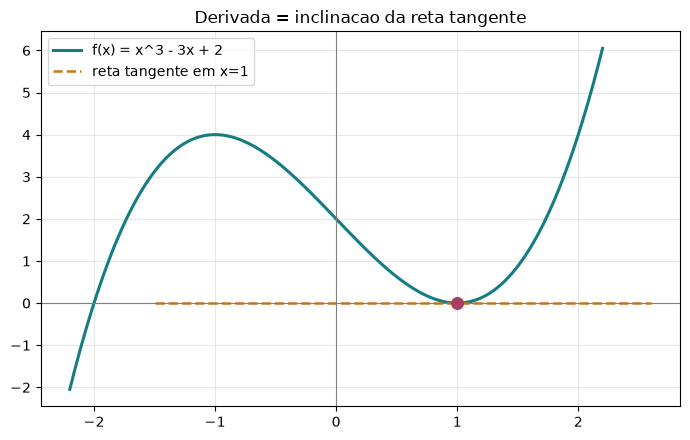


OK - exemplos resolvidos com SymPy (aritmetica simbolica exata).


In [2]:

%matplotlib inline
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
x = sp.symbols("x")

print("=" * 60)
print("1) LIMITE: lim (x^2 - 1)/(x - 1) quando x -> 1  (indeterminacao 0/0)")
print("   ->", sp.limit((x**2 - 1)/(x - 1), x, 1))

print("\n2) LIMITE NOTAVEL: lim sen(x)/x quando x -> 0")
print("   ->", sp.limit(sp.sin(x)/x, x, 0))

print("\n3) DERIVADA: f(x) = x^3 * e^x")
f = x**3 * sp.exp(x)
print("   f'  =", sp.diff(f, x))
print("   f'' =", sp.diff(f, x, 2))

print("\n4) REGRA DA CADEIA: h(x) = sen(x^2 + 3x)")
print("   h'  =", sp.diff(sp.sin(x**2 + 3*x), x))

print("\n5) L'HOPITAL: lim (1 - cos(x))/x^2 quando x -> 0")
print("   ->", sp.limit((1 - sp.cos(x))/x**2, x, 0))

print("\n6) INTEGRAL DEFINIDA: Integral de e^x de 0 a 1")
I = sp.integrate(sp.exp(x), (x, 0, 1))
print("   ->", I, "=", I.evalf())

print("\n7) AREA ENTRE CURVAS: y = x^2 e y = sqrt(x) em [0, 1]")
f7, g7 = x**2, sp.sqrt(x)
A = sp.integrate(g7 - f7, (x, 0, 1))
print("   Area =", A, "=", A.evalf())

print("\n8) RETA TANGENTE de f(x) = x^3 - 3x + 2 em x = 1")
f8 = sp.Lambda(x, x**3 - 3*x + 2)
fp8 = sp.diff(f8(x), x)
a = 1
reta = f8(a) + fp8.subs(x, a) * (x - a)
print("   f'(1) =", fp8.subs(x, a), " -> y =", sp.expand(reta))

xx = np.linspace(-2.2, 2.2, 300)
plt.figure(figsize=(7, 4.5))
plt.plot(xx, [float(f8(i)) for i in xx], lw=2.2, color="#147D82", label="f(x) = x^3 - 3x + 2")
tt = np.linspace(-1.5, 2.6, 10)
plt.plot(tt, [float(reta.subs(x, i)) for i in tt], "--", lw=1.8, color="#C97A1A",
         label="reta tangente em x=1")
plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
plt.scatter([a], [f8(a)], color="#A83E63", zorder=5, s=70)
plt.title("Derivada = inclinacao da reta tangente")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print("\nOK - exemplos resolvidos com SymPy (aritmetica simbolica exata).")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
